In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

In [2]:
ldsc_df = pd.read_csv("../inputs/ldsc/ldsc.all.sumstat.results.txt", sep = "\t")
ldsc_df = ldsc_df.sort_values("h2 - LDSC")
ldsc_df.head()

,Trait,h2 - LDSC,se - LDSC,run time - LDSC,h2 - actual
4,Chiou.Nature.2021.Type_1_diabetes,0.0403,0.0058,30.03s,NaN
0,Wray.biorxiv.2018.Major_Depressive_Disorder,0.0747,0.0055,30.88s,NaN
1,Watson.2018.NatGenet.Anorexia_Nervosa,0.1798,0.0161,29.48s,NaN
3,Grove.NatGenet.2019.Autism_Spectrum_Disorder,0.1923,0.0262,32.44s,NaN
2,PGC.Nature.2014.Schizophrenia,0.4640,0.0182,31.35s,NaN


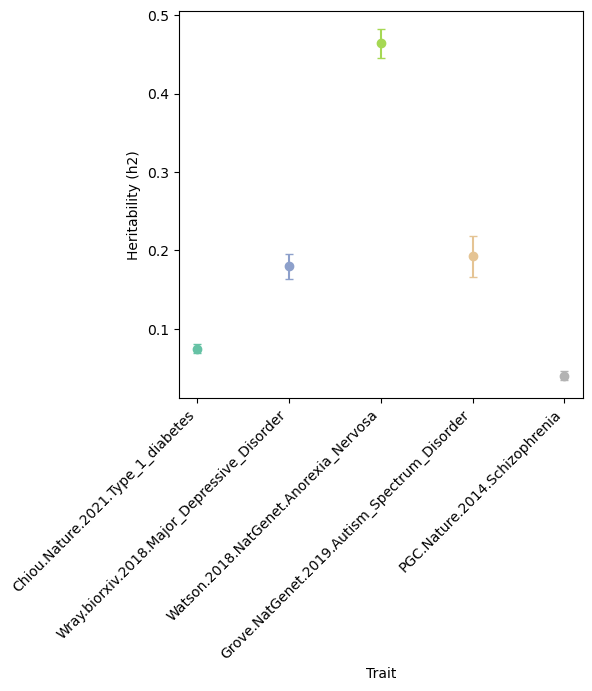

In [3]:
plt.figure(figsize=(6,7))
colors = plt.cm.Set2(np.linspace(0, 1, len(ldsc_df)))
   

for i, row in ldsc_df.iterrows():
    plt.errorbar(
        i,
        row["h2 - LDSC"],
        yerr=row["se - LDSC"],
        fmt='o',
        capsize=3,
        color=colors[i]
    )


plt.xticks(range(len(ldsc_df)), ldsc_df["Trait"], rotation=45, ha="right")

plt.ylabel("Heritability (h2)")
plt.xlabel("Trait")

plt.tight_layout()
plt.show()

In [5]:
ldsc_chr_df = pd.read_csv("../inputs/ldsc/ldsc.one.chr.sumstat.results.txt", sep = "\t")
ldsc_chr_df = ldsc_chr_df.sort_values("h2 - LDSC")

In [6]:
ldsc_chr_df.head()

,Trait,h2 - LDSC,se - LDSC,run time - LDSC,h2 - actual
0,Wray.biorxiv.2018.Major_Depressive_Disorder,-15.0626,8.5128,30.88s,0.40
4,Chiou.Nature.2021.Type_1_diabetes,-9.4143,6.3862,30.03s,0.50
1,Watson.2018.NatGenet.Anorexia_Nervosa,-8.6143,11.9961,29.48s,0.80
3,Grove.NatGenet.2019.Autism_Spectrum_Disorder,7.4190,6.5349,32.44s,0.75
2,PGC.Nature.2014.Schizophrenia,11.9673,11.0639,31.35s,0.60


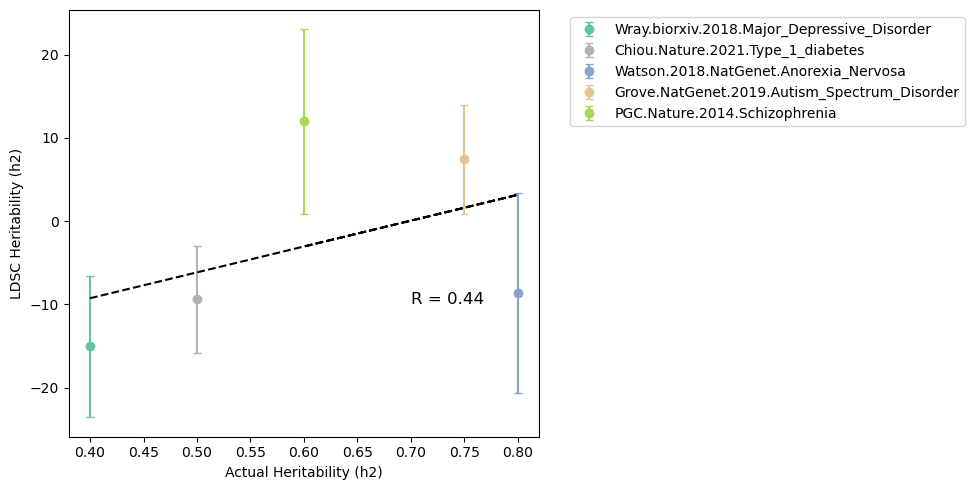

In [28]:
plt.figure(figsize=(10,5))
colors = plt.cm.Set2(np.linspace(0, 1, len(ldsc_chr_df)))

x = ldsc_chr_df["h2 - actual"].values        
y = ldsc_chr_df["h2 - LDSC"].values    

for i, row in ldsc_chr_df.iterrows():
    plt.errorbar(
        row["h2 - actual"],
        row["h2 - LDSC"],
        yerr=row["se - LDSC"],
        fmt='o',
        capsize=3,
        color=colors[i], 
        label=row["Trait"] 
    )

slope, intercept, r_value, p_value, std_err = linregress(x, y)
plt.plot(x, intercept + slope*x, color='black', linestyle='--')

plt.text(
    0.7,                  # x position (5% from left)
    -10,                        # y position (top of plot)
    f"R = {r_value:.2f}",          # formatted text
    fontsize=12,
    color='black'
)

# plt.xticks(range(len(ldsc_chr_df)), ldsc_chr_df["Trait"], rotation=45, ha="right")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylabel("LDSC Heritability (h2)")
plt.xlabel("Actual Heritability (h2)")

plt.tight_layout()
plt.show()